# Aplicação: Remoção de estruturas indesejadas, e identificação de lesões em mamas densas


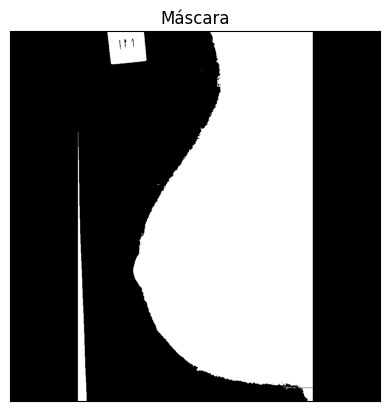

In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
#Gerando a máscara com T=15
img=cv2.imread("mam_ex1.jpg",0)
method = cv2.THRESH_BINARY
ret,imgBin1 = cv2.threshold(img, 30,255, method)
plt.imshow(imgBin1,cmap=plt.cm.gray)
plt.title('Máscara'),plt.xticks([]), plt.yticks([])
plt.show()

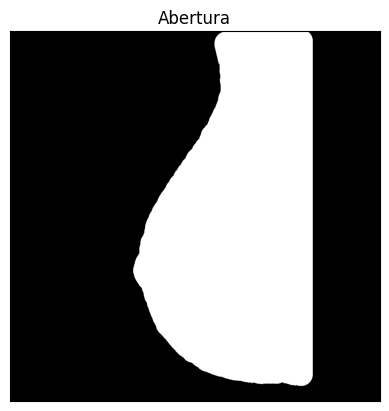

In [6]:
#Aplicação do operador de abertura
kernel=cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (65,65)) # Elemento estruturante em elipse
#kernel=cv2.getStructuringElement(cv2.MORPH_RECT,(50,50))
opening = cv2.morphologyEx(imgBin1, cv2.MORPH_OPEN, kernel)
plt.imshow(opening,cmap=plt.cm.gray)
plt.title('Abertura'),plt.xticks([]), plt.yticks([])
plt.show()

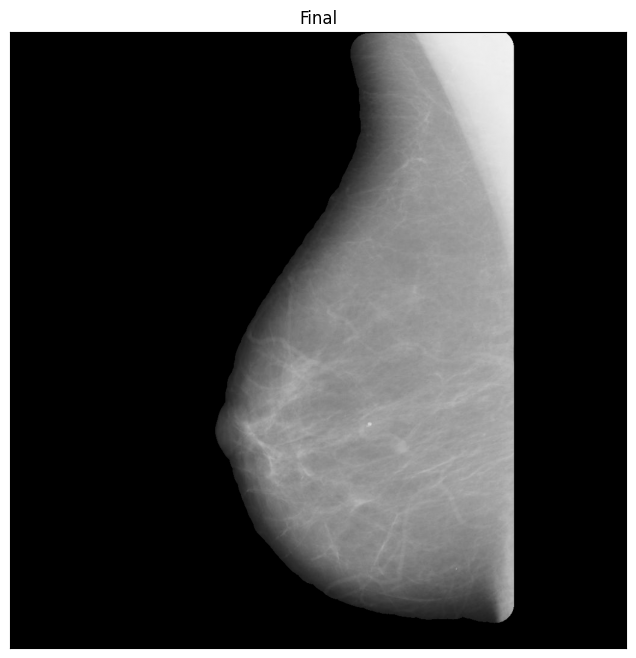

In [7]:
# Resultado final
opening_norm=opening//255
final=img*opening_norm
plt.figure(figsize=(12,8))
plt.imshow(final,cmap=plt.cm.gray)
plt.title('Final'),plt.xticks([]), plt.yticks([])
plt.show()



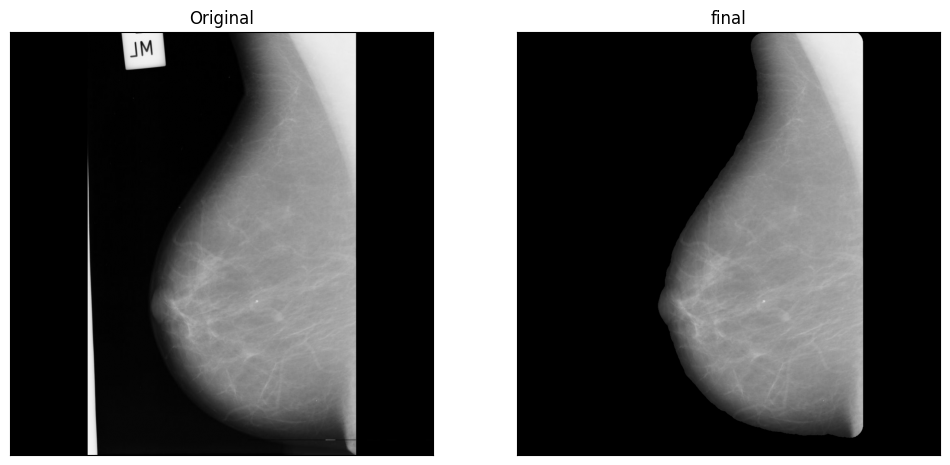

In [8]:
plt.figure(figsize=(12,8))
plt.subplot (1,2,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Original'),plt.xticks([]), plt.yticks([])
plt.subplot (1,2,2)
plt.imshow(final,cmap=plt.cm.gray)
plt.title('final'),plt.xticks([]), plt.yticks([])
plt.show()

# 2. Equalização adaptativa em mamografias


A equalização do histograma de uma imagem pode ser útil para diminuir as regiões de baixo contraste de uma imagem. Entretanto, pode ser ineficiente se a imagem tiver regiões de alto e baixo contraste, ou seja, imagens de contraste muito variável. o código abaixo ilustra a equalização do histograma de uma mamografia

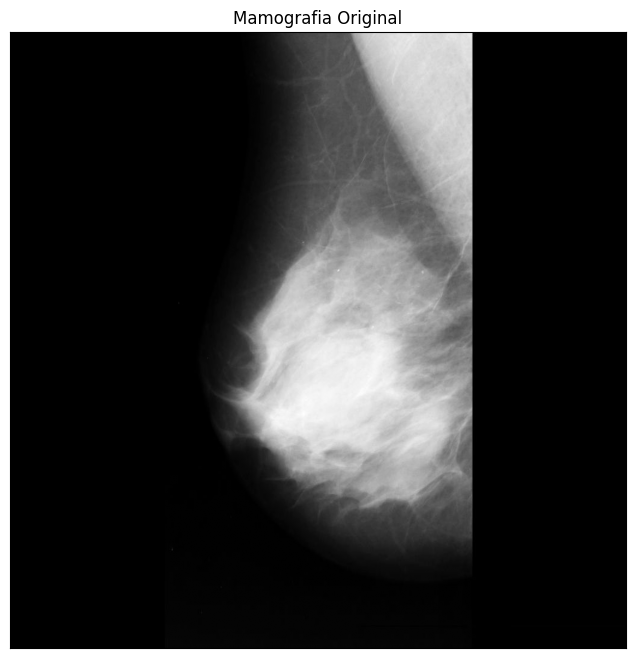

In [14]:
#Carregando a mamografia original e mostrando o histograma
mamog = cv2.imread('mom_clahe.jpg',0)
plt.figure(figsize=(12,8))
plt.imshow(mamog,cmap=plt.cm.gray)
plt.title('Mamografia Original'),plt.xticks([]), plt.yticks([])
plt.show()

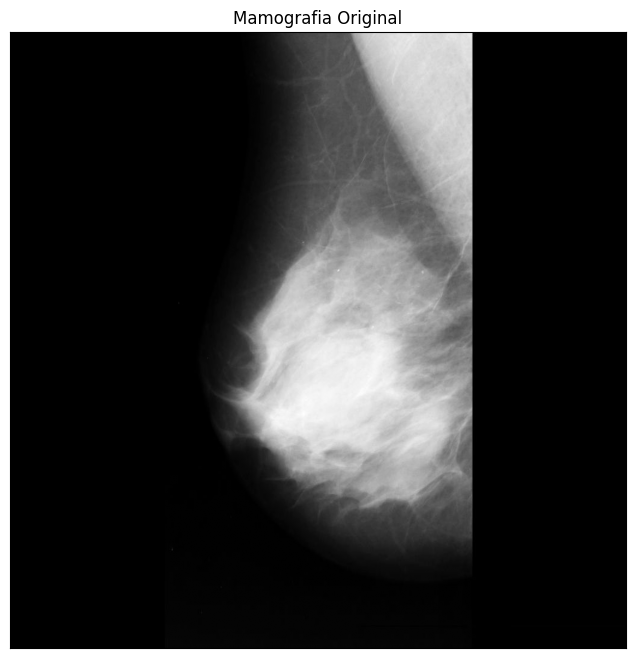

In [ ]:
plt.hist(img.ravel(), 256, [0,256])
plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Número de Pixels")


In [ ]:
#Realizando a Equalização de histograma normal
h_eq = cv2.equalizeHist(mamog)
imgEqualizada = cv2.equalizeHist(mamog)
plt.figure(figsize=(12,8))
plt.imshow(imgEqualizada,cmap=plt.cm.gray)
plt.title('Mamograma equalizado')




In [ ]:
plt.hist(imgEqualizada.ravel(), 256, [0,256])
plt.title("'Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Número de Pixels")



Através da equalização realizada acima, pode se observar uma melhora no contraste da imagem. entretanto, a melhor solução para uma imagem de contrste variável, e a CLAHE - Contrast Limit Adaptive histogram, que realiza uma equalização adapttiva com limitação de contraste na imagem.

Na CLAHE, a imagem é dividida em blocos, onde é calculada a equalização de histograma, com um valor de limiar, chamado de clippng. Valores de intensidade acima do clipping serão distribuidos no histograma da imagem, conforme imagem abaixo:
![image.png](attachment:image.png)

A seguir faremos um código da CLAHE aplicada na mesma mamografia que fizemos a equalização tradicional.

In [ ]:
# create a CLAHE object (Arguments are optional).
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(mamog)

In [ ]:
plt.figure(figsize=(25,20))
plt.subplot (1,3,1)
plt.imshow(mamog,cmap=plt.cm.gray)
plt.title('/original'), plt.xticks([]), plt.yticks([])
plt.subplot (1,3,2)
plt.imshow(imgEqualizada,cmap=plt.cm.gray)
plt.title('Equalização de histograma'), plt.xticks([]), plt.yticks([])
plt.subplot (1,3,3)
plt.imshow(cl1,cmap=plt.cm.gray)
plt.title('CLAHE'), plt.xticks([]), plt.yticks([])

# Tarefa avaliativa

Contrast stretching aplicado no melhoramento de imagens

O Alargamento de constraste é uma técnica que expande uma determinada faixa de níveis de intensidade de modo a incluir todo o intervalo, sendo que a expansão (alargamento) ocorre somente no intervalo determinado pelos parâmetros da função de transformação linear por partes.

Através dos parâmetros (r1,s1) e (r2,s2) no gráfico descrito abaixo, é possivel modificar o invervalo de contraste da imagem

![image.png](attachment:image.png)



Abaixo um exemplo de contrast stretching. A sua tarefa é encontrar os prâmetros ideias até a imagem ficar com o
contraste equivalente à mamografia abaixo.

![res_aproximado.png](attachment:res_aproximado.png)

É válido ressaltar que o tecido mais claro da mamografia é uma lesão  (tumor) que estava escondido atras do tecido mamário sadio

Abaixo um exemplo de código

In [ ]:
def pixelVal(pix, r1, s1, r2, s2):
	if (0 <= pix and pix <= r1):
		return (s1 / r1)*pix
	elif (r1 < pix and pix <= r2):
		return ((s2 - s1)/(r2 - r1)) * (pix - r1) + s1
	else:
		return ((255 - s2)/(255 - r2)) * (pix - r2) + s2

In [ ]:
# Define parameters.
r1 = 215
s1 = 100
r2 = 220
s2 = 250
pixelVal_vec = np.vectorize(pixelVal)
contrast_stretched = pixelVal_vec(cl1, r1, s1, r2, s2)
plt.figure(figsize=(15,10))
plt.imshow(contrast_stretched,cmap=plt.cm.gray)